# Ranking and Change Charts (Solution)

Use lollipop, slope, bump, and dumbbell charts for rank and change narratives.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style="whitegrid")

def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "data" / "owid_co2_subset.csv").exists():
            return p
    raise FileNotFoundError("Cannot locate data/owid_co2_subset.csv")

root = resolve_repo_root()
df = pd.read_csv(root / "data" / "owid_co2_subset.csv")
df = df[df["iso_code"].astype(str).str.len() == 3].copy()
d_recent = df[df["year"] >= 2000].copy()
latest_year = (
    d_recent.dropna(subset=["co2_per_capita", "gdp", "population"])
    ["year"]
    .max()
)
d_latest = d_recent[d_recent["year"] == latest_year].copy()
d_latest.head()

,country,year,iso_code,population,gdp,co2,co2_per_capita,coal_co2,energy_per_capita,gas_co2,methane,nitrous_oxide,oil_co2,primary_energy_consumption,temperature_change_from_ghg,trade_co2
32,Afghanistan,2022,AFG,40578847.0,5.330347e+10,10.170,0.251,3.488,1111.573,0.143,16.076,4.419,6.528,45.106,0.001,NaN
67,Albania,2022,ALB,2827614.0,3.617101e+10,4.498,1.591,0.542,9147.205,0.088,2.431,0.864,2.946,25.865,0.000,1.188
102,Algeria,2022,DZA,45477391.0,5.958201e+11,192.779,4.239,0.758,16145.337,101.379,67.576,8.200,61.610,734.248,0.005,NaN
137,Andorra,2022,AND,79722.0,NaN,0.423,5.311,0.000,NaN,0.007,0.079,0.038,0.416,NaN,0.000,NaN
172,Angola,2022,AGO,35635028.0,1.583462e+11,21.089,0.592,NaN,2713.824,1.927,45.564,17.332,14.887,96.707,0.006,NaN


## 1) Lollipop chart

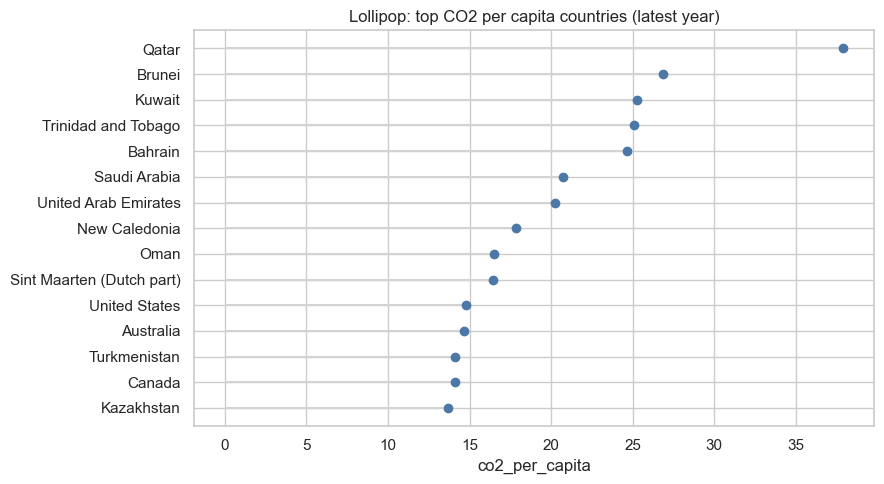

In [2]:
agg = (
    d_latest.dropna(subset=['co2_per_capita'])
    .groupby('country', as_index=False)['co2_per_capita']
    .mean()
    .nlargest(15, 'co2_per_capita')
    .sort_values('co2_per_capita')
)

plt.figure(figsize=(9,5))
plt.hlines(y=agg['country'], xmin=0, xmax=agg['co2_per_capita'], color='lightgray')
plt.plot(agg['co2_per_capita'], agg['country'], 'o', color='#4C78A8')
plt.title('Lollipop: top CO2 per capita countries (latest year)')
plt.xlabel('co2_per_capita')
plt.tight_layout(); plt.show()

## 2) Slope chart (1997 vs 2007)

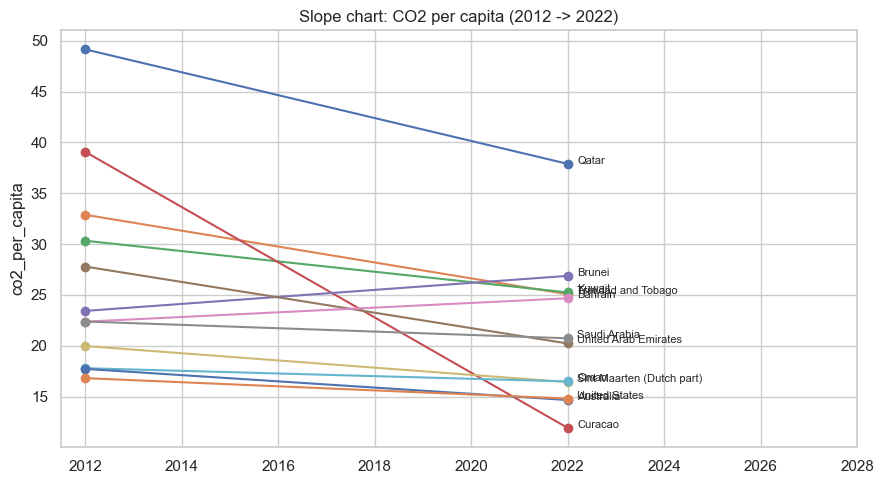

In [3]:
last_year = int(d_latest['year'].max())
first_year = max(2000, last_year - 10)
a = d_recent[d_recent['year'].isin([first_year, last_year])].dropna(subset=['co2_per_capita'])
a = a.groupby(['country','year'], as_index=False)['co2_per_capita'].mean()
# keep countries with both years and large absolute levels for readability
pivot = a.pivot(index='country', columns='year', values='co2_per_capita').dropna()
keep = pivot.mean(axis=1).nlargest(12).index
pvt = pivot.loc[keep]

plt.figure(figsize=(9,5))
for c in pvt.index:
    plt.plot([first_year, last_year], [pvt.loc[c, first_year], pvt.loc[c, last_year]], marker='o')
    plt.text(last_year + 0.2, pvt.loc[c, last_year], c, fontsize=8)
plt.title(f'Slope chart: CO2 per capita ({first_year} -> {last_year})')
plt.xlim(first_year - 0.5, last_year + 6)
plt.ylabel('co2_per_capita')
plt.tight_layout(); plt.show()

## 3) Dumbbell chart

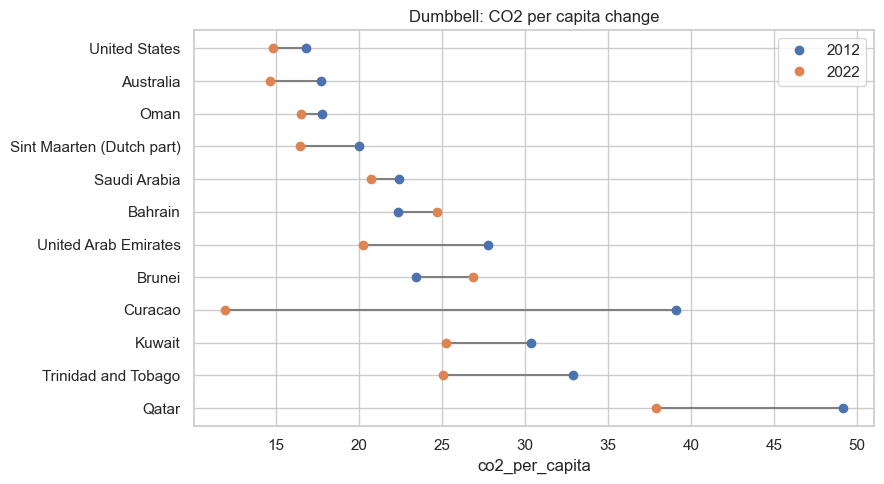

In [4]:
x = pvt[first_year]
y = pvt[last_year]
countries = pvt.index
plt.figure(figsize=(9,5))
plt.hlines(countries, x, y, color='gray')
plt.plot(x, countries, 'o', label=str(first_year))
plt.plot(y, countries, 'o', label=str(last_year))
plt.legend(); plt.title('Dumbbell: CO2 per capita change')
plt.xlabel('co2_per_capita')
plt.tight_layout(); plt.show()

## Reflection
- Nêu 2 điểm học được về chart selection.
- Chỉ ra 1 rủi ro diễn giải sai với loại chart trong lab này.